# Synthetic Image Classification with a CNN — "Real vs. Fake Logo" Proof of Concept

**What this project actually is, stated plainly up front:** a from-scratch, code-generated synthetic dataset is used to build and validate a small CNN image classification pipeline end-to-end — data generation, preprocessing, model design, training, and evaluation. The two classes ("real" logos: a plain black circle with text; "fake" logos: a randomly colored, blurred ellipse) are generated by two different, deterministic drawing functions, making them structurally very easy to separate. This is why the model reaches 100% test accuracy — **that number reflects how visually distinct the two synthetic classes are, not real-world fake-logo detection performance.**

**Why build this anyway:** working with real counterfeit-logo data requires either a licensed dataset or scraping/labeling real brand logos (both non-trivial, and the latter raises copyright concerns for a portfolio project). This project instead demonstrates the full CNN pipeline — image generation/loading, preprocessing, `Conv2D`/`MaxPooling2D` architecture design, training with validation, and evaluation with a confusion matrix — on a controlled synthetic dataset where the "correct answer" is unambiguous, which makes it a clean way to verify every step of the pipeline works correctly before applying it to messier real-world data.

**What a real version of this would need:** an actual labeled dataset of genuine vs. counterfeit product logos (several exist as research datasets, e.g. for brand protection use cases), and the accuracy on that data would almost certainly be well below 100% — real counterfeits are specifically designed to *not* be easily distinguishable, which is precisely what makes the real problem hard and the reported number here inapplicable to it.


In [1]:
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

## 1. Reproducibility

Fixed random seeds so the synthetic dataset and train/test split are identical on every run — important for a synthetic-data project specifically, since without this, re-running the notebook would silently generate a different (though similarly easy) dataset each time.


In [2]:
np.random.seed(42)
random.seed(42)

## 2. Dataset generation

Two folders, `real/` and `fake/`, are created and populated entirely by code — no external download needed, which also means this notebook is fully reproducible by anyone who clones it, with no dataset licensing or download-link rot to worry about.


In [3]:
base_dir = "logo_dataset"
real_dir = os.path.join(base_dir, "real")
fake_dir = os.path.join(base_dir, "fake")

os.makedirs(real_dir, exist_ok=True)
os.makedirs(fake_dir, exist_ok=True)

In [4]:
IMG_SIZE = 128
NUM_IMAGES = 200

**"Real" logos**: a fixed black circle with "LOGO" text, drawn identically (same size, same color, same position) every time.


In [5]:
def create_real_logo(path):
    img = np.ones((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8) * 255
    color = (0, 0, 0)
    cv2.circle(img, (64, 64), 40, color, -1)
    cv2.putText(img, "LOGO", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)
    cv2.imwrite(path, img)

**"Fake" logos**: a colored ellipse (random color and rotation) with Gaussian noise and blur applied — deliberately built to look visually distinct from the "real" class, since the goal here is validating the pipeline, not simulating subtle counterfeiting.


In [6]:
def create_fake_logo(path):
    img = np.ones((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8) * 255
    color = (random.randint(0,255), random.randint(0,255), random.randint(0,255))
    cv2.ellipse(img, (64, 64), (40,30), random.randint(0,180),
                0, 360, color, -1)

    noise = np.random.randint(0,50,(IMG_SIZE,IMG_SIZE,3), dtype=np.uint8)
    img = cv2.add(img, noise)
    img = cv2.GaussianBlur(img,(5,5),0)

    cv2.imwrite(path, img)

In [7]:
for i in range(NUM_IMAGES):
    create_real_logo(os.path.join(real_dir, f"real_{i}.png"))
    create_fake_logo(os.path.join(fake_dir, f"fake_{i}.png"))

print("Dataset Generated Successfully!")

Dataset Generated Successfully!


## 3. Load and preprocess

Images are read back from disk, resized to a consistent shape, and pixel values normalized to [0, 1]. Labels are one-hot encoded for the two-class softmax output used below.


In [8]:
data = []
labels = []

for label, folder in enumerate([real_dir, fake_dir]):
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        data.append(img)
        labels.append(label)

data = np.array(data) / 255.0
labels = to_categorical(labels, 2)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

## 4. Model — a standard small CNN

Three convolutional blocks (increasing filter depth: 32 → 64 → 128) followed by dense layers with dropout for regularization — a conventional, well-tested architecture for small-image binary classification, appropriately sized for a 400-image dataset (a larger/deeper network would be more prone to overfitting on this little data).


In [10]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

D:\Ana Python\envs\mlprojects\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Training


In [11]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=16
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 446ms/step - accuracy: 0.9312 - loss: 0.1416 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 252ms/step - accuracy: 1.0000 - loss: 7.1713e-06 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 228ms/step - accuracy: 1.0000 - loss: 1.2385e-05 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 221ms/step - accuracy: 1.0000 - loss: 1.3189e-05 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 221ms/step - accuracy: 1.0000 - loss: 1.5646e-08 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 1.0000 - loss: 3.7253e-10 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 256ms/step - accuracy: 1.0000 - loss: 4.5892e-07 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 229ms/ste

## 6. Evaluation


In [12]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# ---------- CONFUSION MATRIX ----------
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Real Logo", "Fake Logo"]))


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Test Accuracy: 100.00%
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step

Confusion Matrix:
[[44  0]
 [ 0 36]]

Classification Report:
              precision    recall  f1-score   support

   Real Logo       1.00      1.00      1.00        44
   Fake Logo       1.00      1.00      1.00        36

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



**Result: 100% test accuracy — expected and explained above, not a claim of real-world performance.** The confusion matrix and classification report below confirm the model correctly separates every synthetic "real" and "fake" sample in the held-out test set, which is exactly what should happen when two classes are generated by two visually distinct, deterministic functions.


## 7. Visualizing a single prediction


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


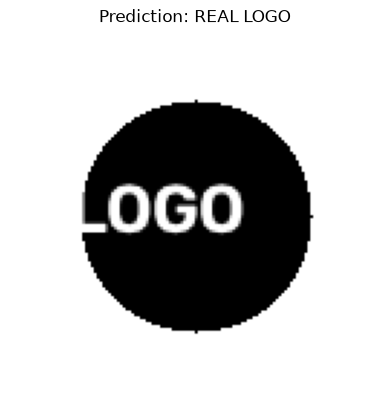

In [13]:
import matplotlib.pyplot as plt
test_img = X_test[2]
prediction = model.predict(np.expand_dims(test_img, axis=0))
label = np.argmax(prediction)

plt.imshow(test_img)
plt.title("Prediction: " + ("REAL LOGO" if label == 0 else "FAKE LOGO"))
plt.axis("off")
plt.show()

## Summary

| Step | Result |
|---|---|
| Dataset | 400 synthetic images (200 real, 200 fake), generated in-code |
| Model | 3-block CNN, ~400K parameters |
| Test accuracy | 100% (on synthetic, visually distinct classes — see note above) |

**What I'd improve with more time:** replace the synthetic dataset with a real labeled brand-logo dataset (genuine vs. counterfeit product logos) and re-report accuracy on that — the honest expectation is a substantially lower, more meaningful number, since real counterfeits are designed to look convincing rather than being trivially distinguishable by color and shape as here.
